In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import cdsapi
from xmca.xarray import xMCA
import rioxarray


# GDP

In [2]:
res = '0_25deg'  # '0_5deg' or '1deg'

if res == '1deg':
    cell_string = "cell_id"
elif res == '0_5deg':
    cell_string = "subcell_id"
elif res == '0_25deg':
    cell_string = "subcell_id_0_25"

In [3]:
gdp = pd.read_csv(f'raw data/{res}/final_GDPC_{res}_postadjust_pop_dens_no_extra_adjust.csv')

In [4]:
gdp.columns

Index(['iso', 'year', 'cell_id', 'subcell_id', 'subcell_id_0_25',
       'predicted_GCP_const_2021_USD', 'predicted_GCP_current_USD',
       'predicted_GCP_const_2021_PPP', 'predicted_GCP_current_PPP', 'pop_cell',
       'cell_GDPC_const_2021_USD', 'cell_GDPC_current_USD',
       'cell_GDPC_const_2021_PPP', 'cell_GDPC_current_PPP', 'is_cell_censored',
       'method', 'cell_size', 'longitude', 'latitude', 'national_population'],
      dtype='object')

In [5]:
gdp_agg = (
    gdp
    .groupby(["year", "latitude", "longitude"], as_index=False)
    .agg(
        GDPPC=("cell_GDPC_current_USD", "mean"),
        GDP =("predicted_GCP_current_USD", "mean"),
        pop_cell=("pop_cell", "mean"),
        cell_id =(cell_string, "first"),
        national_population =("national_population", "first"),
        country =("iso", "first"),
    )
)


ds = (
    gdp_agg
    .set_index(["year", "latitude", "longitude"])
    [["GDPPC", 'GDP', "pop_cell", "cell_id", "national_population", "country"]]
    .to_xarray()
)

# optional but recommended
ds = ds.sortby(["year", "latitude", "longitude"])
ds = ds.rename({"latitude": "lat", "longitude": "lon"})


ds["GDPPC"] = ds["GDPPC"].where(
    ds["pop_cell"] > 0
)

#add loggdp variable
ds["loggdp"] = np.log(ds["GDPPC"])  # add 1 to avoid log(0)
#compute growth per latlon
ds["growth"] = ds["loggdp"].diff("year")


c:\Users\emile\anaconda3\envs\econ-disasters\Lib\site-packages\xarray\computation\apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


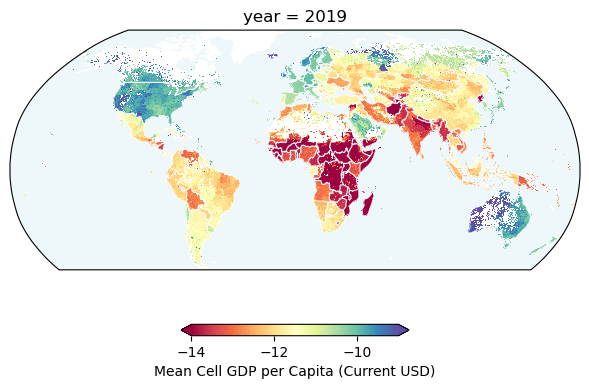

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

da = ds["loggdp"].sel(year=2019)

cmap = plt.cm.Spectral.copy()

fig, ax = plt.subplots(
    figsize=(6, 4),
    subplot_kw=dict(projection=ccrs.Robinson())
)

ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.2)

da.plot(
    ax=ax,
    cmap=cmap,
    vmin = -14,
    vmax = -9,
    add_colorbar=True,
    cbar_kwargs={"label": "Mean Cell GDP per Capita (Current USD)", "shrink": 0.4, "orientation": "horizontal"},
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.COASTLINE, edgecolor="white", linewidth=0.6)
ax.add_feature(cfeature.BORDERS, edgecolor="white", linewidth=0.8)

plt.tight_layout()
plt.savefig(f'figures/local_gdp.png', dpi=300)
plt.show()


# NEW GDP

In [15]:
ds = xr.open_dataset(f'raw data/rast_adm2_gdp_perCapita_1990_2022_30arcmin.tif', engine='rasterio')
# Create year coordinate (1990–2022)
years = np.arange(1990, 1990 + ds.dims["band"])

# Convert to (time, lat, lon)
gdp = (
    ds["band_data"]
    .rename({"band": "year", "y": "lat", "x": "lon"})
    .assign_coords(year=years)
)

gdp["year"] = np.arange("1990", "2023", dtype="datetime64[Y]")
gdp['loggdp'] = np.log(1+gdp)
gdp['growth'] = gdp['loggdp'] - gdp['loggdp'].shift(year=1)

C:\Users\emile\AppData\Local\Temp\ipykernel_16084\2395952127.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  years = np.arange(1990, 1990 + ds.dims["band"])


# Temp


In [16]:
temp = xr.open_dataset('raw data/berkeley_temp.nc').rename({'latitude':'lat', 'longitude':'lon'})
#convert lon from 0-360 to -180 to 180
temp = temp.assign_coords(lon=(((temp.lon + 180) % 360) - 180)).sortby('lon')

temp = temp.sel(time=slice('1940-01-01', '2025-12-31')) 


time_frac = temp["time"].values
years = np.floor(time_frac).astype(int)
months = np.round((time_frac - years) * 12).astype(int) + 1
months = np.clip(months, 1, 12)

temp = temp.assign_coords(
    time=pd.to_datetime(
        {"year": years, "month": months, "day": 1}
    )
)

# ---- 2. Add month coordinate ----
temp = temp.assign_coords(month=temp.time.dt.month)

clim = (
    temp["climatology"]
    .assign_coords(month=temp["climatology"]["month_number"] + 1)
    .swap_dims({"month_number": "month"})
)

# 3. Reconstruct total temperature (anomaly + climatology)
temp["total_temperature"] = (
    temp["temperature"]
    .groupby("month")
    + clim
)


# Aggregate and merge


In [17]:
# ensure time is datetime
temp["time"] = pd.to_datetime(temp["time"].values)
da = temp["total_temperature"]  # your DataArray

# yearly mean and max
da_mean = da.groupby("time.year").mean(dim="time")
da_max  = da.groupby("time.year").max(dim="time")

# combine into a Dataset
temp_year = xr.Dataset({
    "mean_temp": da_mean,
    "max_temp": da_max
})

# convert to pandas DataFrame
df_clim = temp_year.to_dataframe().reset_index()


In [21]:

# 1Interpolate temperature to GDP grid
lat_gdp = gdp["lat"].values
lon_gdp = gdp["lon"].values

# temp has NaNs over ocean
temp_on_gdp = temp_year.interp(
    lat=lat_gdp,
    lon=lon_gdp,
    method="nearest"
)


df_temp_on_gdp = temp_on_gdp.to_dataframe().reset_index()

# 3️⃣ Convert GDP to DataFrame (NaNs remain)
df_gdp = gdp.to_dataframe().reset_index()
df_gdp['year'] = df_gdp['year'].dt.year  # extract year as integer

# 4️⃣ Merge on year, lat, lon
df_merged = df_gdp.merge(
    df_temp_on_gdp,
    on=["year", "lat", "lon"],
    how="left"
)

df_merged['latlon'] = df_merged['lat'].astype(str) + '_' + df_merged['lon'].astype(str)

#replace inf values resulting from division by zero with NaN
df_merged.replace([np.inf, -np.inf], np.nan, inplace=True)

In [22]:
df_merged.to_csv(f'processed data/gdp_temp_{res}.csv', index=False)

In [23]:
# True for every row that is duplicated
duplicates_bool = df_merged.duplicated(keep=False)

# show all duplicated rows
df_merged[duplicates_bool]


,year,lat,lon,spatial_ref,loggdp,growth,band_data,mean_temp,max_temp,latlon


# TC

In [ ]:

tc = xr.open_dataset('raw data/gswp3-w5e5_obsclim_sfcwind_global_daily_2011_2019.nc')
#create year;y dataset using max wind speed
tc_year_max = tc['sfcwind'].groupby('time.year').max(dim='time')

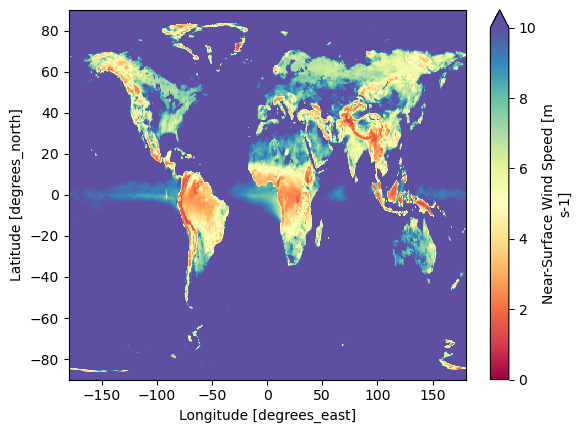

In [ ]:
tc_year_max.mean('year').plot(cmap='Spectral',vmin=0,vmax=10)

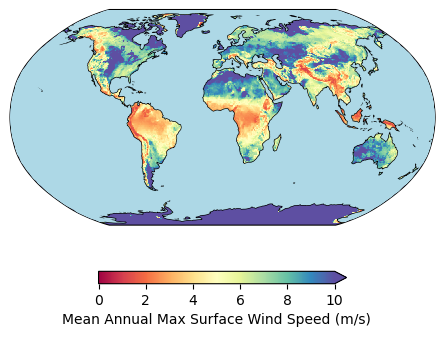

In [ ]:
fig, ax = plt.subplots(
    figsize=(8, 4),
    subplot_kw={"projection": ccrs.Robinson()}
)

tc_year_max.mean("year").plot(
    ax=ax,
    cmap="Spectral",
    vmin=0,
    vmax=10,
        add_colorbar=True,
        cbar_kwargs={"label": "Mean Annual Max Surface Wind Speed (m/s)", "shrink": 0.4, "orientation": "horizontal"},
    transform=ccrs.PlateCarree()
)

# Add ocean mask
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=10)
ax.coastlines()

plt.show()

In [ ]:

tc_on_gdp = tc_year_max.interp(
    lat=ds.lat,
    lon=ds.lon,
    method="nearest"
)

tc_on_gdp = tc_on_gdp.where(ds["pop_cell"] > 0)


ds = ds.assign(wind=tc_on_gdp)

ds['growth_t1'] = ds['loggdp'].shift(year=-1) - ds['loggdp']

df_merged = (
    ds[["wind", "loggdp", "growth", "pop_cell", "country"]]
    .to_dataframe()
    .reset_index()
)

# clean infinities just in case
df_merged.replace([np.inf, -np.inf], np.nan, inplace=True)

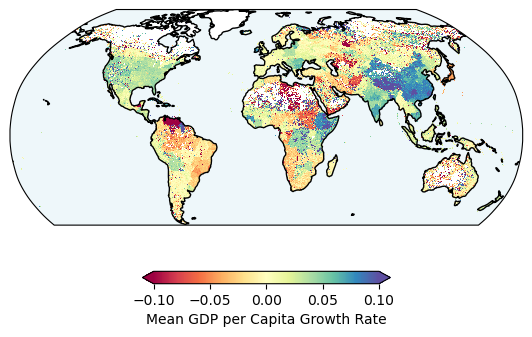

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(8, 4),
    subplot_kw={"projection": ccrs.Robinson()}
)

ds["growth"].mean("year").plot(
    ax=ax,
    vmin=-0.1,
    vmax=0.1,
    cmap="Spectral",
    cbar_kwargs={"label": "Mean GDP per Capita Growth Rate", "shrink": 0.4, "orientation": "horizontal"},
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.2)
ax.coastlines()
plt.savefig('figures/local_growth.png', dpi=300, bbox_inches='tight')
plt.show()


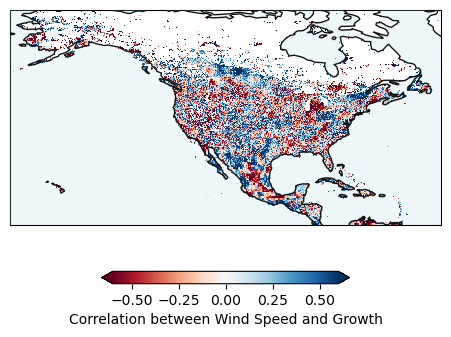

In [ ]:
fig, ax = plt.subplots(
    figsize=(8, 4),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

xr.corr(
    ds["wind"],
    ds["growth"],
    dim="year"
).plot(
    ax=ax,
    vmin=-0.6,
    vmax=0.6,
    cmap="RdBu",
    transform=ccrs.PlateCarree(),
    cbar_kwargs={
        "label": "Correlation between Wind Speed and Growth",
        "shrink": 0.4,
        "orientation": "horizontal"
    }
)

# Ocean mask + coastlines (same as other panels)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.2, zorder=10)
ax.coastlines()
#zoom on north america
ax.set_extent([-170, -50, 10, 70], crs=ccrs.PlateCarree())

plt.show()

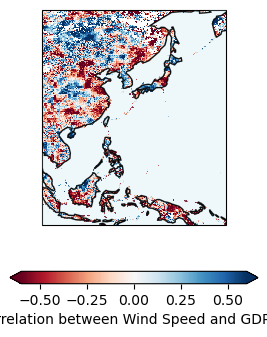

In [ ]:
fig, ax = plt.subplots(
    figsize=(8, 4),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
xr.corr(
    ds["wind"],
    ds["growth_t1"],
    dim="year"
).plot(
    ax=ax,
    vmin=-0.6,
    vmax=0.6,
    cmap="RdBu",
    transform=ccrs.PlateCarree(),
    cbar_kwargs={
        "label": "Correlation between Wind Speed and GDP pc",
        "shrink": 0.4,
        "orientation": "horizontal"
    }
)

# Ocean mask + coastlines (same as other panels)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.2, zorder=10)
ax.coastlines()
#zoom on japan/ philippines
ax.set_extent([100, 160, -10, 60], crs=ccrs.PlateCarree())

plt.show()

In [ ]:
df_merged.to_csv(f'processed data/gdp_tc_{res}.csv', index=False)

# Plots

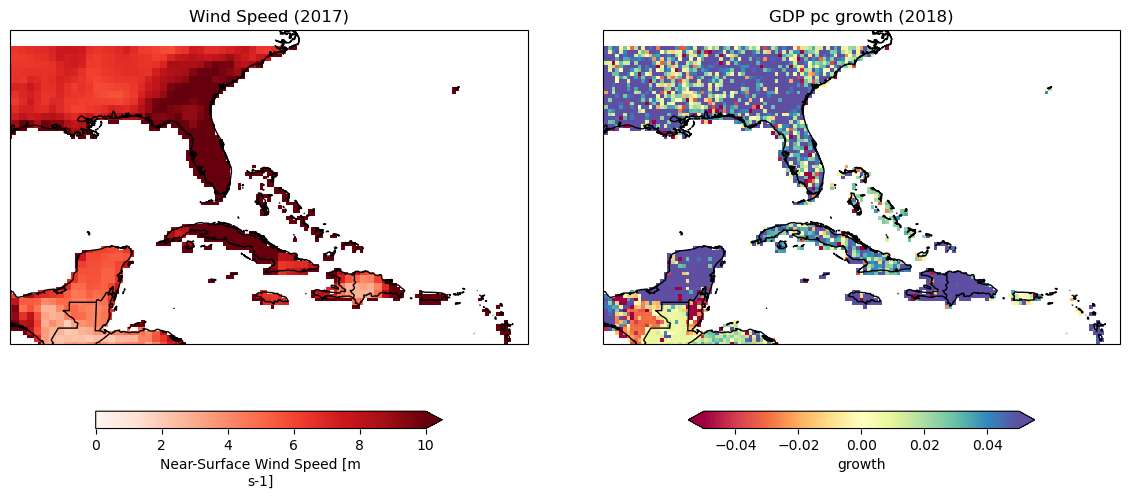

In [ ]:
fig, axs = plt.subplots(
    1, 2, figsize=(12, 5),
    subplot_kw=dict(projection=ccrs.PlateCarree())
)

extent_carrib = [-95, -60, 15, 35]

# --- TC field
p1 = tc_on_gdp.sel(
    year=2017, lat=slice(extent_carrib[2], extent_carrib[3]), lon=slice(extent_carrib[0], extent_carrib[1])
).plot(
    ax=axs[0],
    transform=ccrs.PlateCarree(),
    add_colorbar=True,
    cmap = 'Reds',
    vmin=0,
    vmax=10,
    
    cbar_kwargs={"orientation": "horizontal", "shrink": 0.6}
)
axs[0].set_title("Wind Speed (2017)")
axs[0].set_extent(extent_carrib)

# --- GDP field
p2 = ds["growth"].sel(
    year=2018, lat=slice(extent_carrib[2], extent_carrib[3]), lon=slice(extent_carrib[0], extent_carrib[1])
).plot(
    ax=axs[1],
    transform=ccrs.PlateCarree(),
    cmap="Spectral",
    add_colorbar=True,
    vmin=-0.05,
    vmax=0.05,
    cbar_kwargs={"orientation": "horizontal", "shrink": 0.6}
)
axs[1].set_title("GDP pc growth (2018)")
axs[1].set_extent(extent_carrib)

for ax in axs:
    ax.coastlines("10m")
    ax.add_feature(cfeature.BORDERS)

plt.tight_layout()
plt.savefig('figures/tc_gdp_local.png', dpi=300)
plt.show()

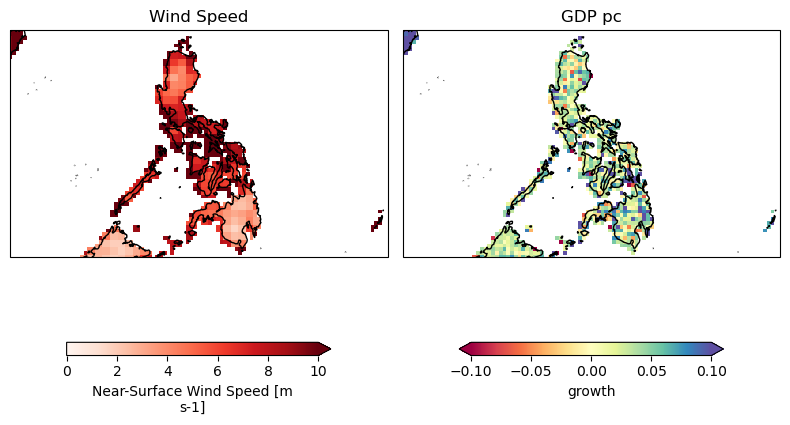

In [ ]:
fig, axs = plt.subplots(
    1, 2, figsize=(8, 6),
    subplot_kw=dict(projection=ccrs.PlateCarree())
)

extent_ph = [110, 135, 5, 20]

# TC field
tc_on_gdp.sel(year=2013, lat=slice(extent_ph[2], extent_ph[3]), lon=slice(extent_ph[0], extent_ph[1])).plot(
    ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=True, cmap='Reds', vmin=0, vmax=10,
    cbar_kwargs={"orientation": "horizontal", "shrink": 0.7}
)
axs[0].set_title("Wind Speed")
axs[0].set_extent(extent_ph)

# GDP field
ds["growth"].sel(year=2014, lat=slice(extent_ph[2], extent_ph[3]), lon=slice(extent_ph[0], extent_ph[1])).plot(
    ax=axs[1],
    transform=ccrs.PlateCarree(),
    cmap="Spectral",
    add_colorbar=True,
    vmin=-0.1,
    vmax=0.1,
    cbar_kwargs={"orientation": "horizontal", "shrink": 0.7}
)
axs[1].set_title("GDP pc")
axs[1].set_extent(extent_ph)

for ax in axs:
    ax.coastlines("10m")
    ax.add_feature(cfeature.BORDERS)

plt.tight_layout()
plt.show()


# MCA

In [ ]:
sst = xr.open_dataset('raw data/sst.mon.mean.nc').sortby('time').sel(time=slice('1900-01-01', '2024-12-31'))
#do yearly mean
sst_year = sst.groupby('time.year').mean('time')
sst_year = sst_year.rename({'year': 'time'})
#to datetime
sst_year['time'] = pd.to_datetime(sst_year['time'].values, format='%Y')

In [ ]:
ds = xr.open_dataset(f'raw data/rast_adm2_gdp_perCapita_1990_2022_30arcmin.tif', engine='rasterio')
# Create year coordinate (1990–2022)
years = np.arange(1990, 1990 + ds.dims["band"])

# Convert to (time, lat, lon)
gdp = (
    ds["band_data"]
    .rename({"band": "time", "y": "lat", "x": "lon"})
    .assign_coords(time=years)
)

gdp["time"] = np.arange("1990", "2023", dtype="datetime64[Y]")
gdp['loggdp'] = np.log(1+gdp)
gdp['growth'] = gdp['loggdp'] - gdp['loggdp'].shift(time=1)

C:\Users\emile\AppData\Local\Temp\ipykernel_15584\3853506028.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  years = np.arange(1990, 1990 + ds.dims["band"])


In [ ]:
left = sst_year.sst
right = gdp["growth"]


from scipy.signal import detrend as scipy_detrend

#match time dimension
left = left.sel(time=right.time)
right = right.sel(time=left.time)

def xr_detrend(da):
    return xr.apply_ufunc(
        scipy_detrend,
        da,
        input_core_dims=[['time']],
        output_core_dims=[['time']],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[da.dtype]
            )
left = xr_detrend(left.fillna(0)).transpose('time','lat','lon')
right = xr_detrend(right.fillna(0)).transpose('time','lat','lon')

In [ ]:
left = (left - left.mean(dim='time', skipna=True)) / (left.std(dim='time', skipna=True) + 1e-6)
right = (right - right.mean(dim='time', skipna=True)) / (right.std(dim='time', skipna=True) + 1e-6)

mca = xMCA(left.fillna(0), right.fillna(0))
mca.apply_coslat()
mca.solve()


In [ ]:
from scipy.stats import pearsonr

def pc_grid_corr(field, pc):
    """
    field : DataArray (time, lat, lon)
    pc    : DataArray (time,)
    """
    def _corr(ts, pc):
        mask = np.isfinite(ts) & np.isfinite(pc)
        if mask.sum() < 3:
            return np.nan, np.nan
        if np.all(ts[mask] == ts[mask][0]):
            return np.nan, np.nan
        r, p = pearsonr(ts[mask], pc[mask])
        return r, p

    r, p = xr.apply_ufunc(
        _corr,
        field,
        pc,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float],
    )

    return r, p


In [ ]:
n_modes = 1
alpha = 0.1

results = []

for i in range(n_modes):

    # PCs (already normalized by construction, but safe)
    pcL = mca.pcs()["left"].sel(mode=i+1)
    pcR = mca.pcs()["right"].sel(mode=i+1)

    pcL = (pcL - pcL.mean()) / pcL.std()
    pcR = (pcR - pcR.mean()) / pcR.std()

    r_pc = np.corrcoef(pcL, pcR)[0, 1]

    left, pcR = xr.align(left, pcR, join="inner")
    right, pcL = xr.align(right, pcL, join="inner")

    # PC–grid correlations
    left_map,  left_p = pc_grid_corr(left,  pcR)
    right_map, right_p = pc_grid_corr(right, pcL)

    # Mask non-significant
    left_map  = left_map.where(left_p  <= alpha)
    right_map = right_map.where(right_p <= alpha)

    #flip left map if enso region is positive and right map is negative (or vice versa), to ensure consistent interpretation of modes
    enso_region = (slice(5, -5), slice(170, 240))  # lat, lon bounds for ENSO region
    enso_corr = left_map.sel(lat=enso_region[0], lon=enso_region[1]).mean()
    if enso_corr < 0:
        left_map = -left_map
        right_map = -right_map

    # Explained covariance
    expl_covar = mca.explained_variance()[i] / 100

    results.append({
        "mode": i+1,
        "pc_corr": r_pc,
        "explained_covariance": expl_covar
    })


C:\Users\emile\AppData\Local\Temp\ipykernel_15584\2308748476.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


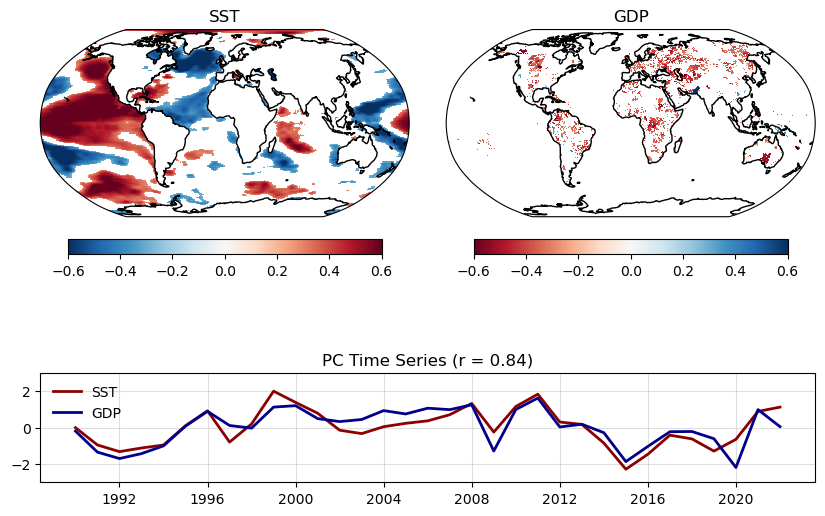

In [ ]:
fig = plt.figure(figsize=(10, 8))

# ---- GRID SPEC ----
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    height_ratios=[2, 0.5],
    hspace=0.25, wspace=0.1
)

# ---- MAPS (TOP ROW, ROBINSON) ----
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.Robinson())
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.Robinson())

# Left map
pcm1 = ax1.pcolormesh(
    left_map.lon, left_map.lat, left_map,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r", vmin=-0.6, vmax=0.6
)
ax1.coastlines()
ax1.set_title("SST", fontsize=12)
cb1 = fig.colorbar(
    pcm1, ax=ax1, orientation="horizontal",
    pad=0.05, shrink=0.85
)

# Right map
pcm2 = ax2.pcolormesh(
    right_map.lon, right_map.lat, right_map,
    transform=ccrs.PlateCarree(),
    cmap="RdBu", vmin=-0.6, vmax=0.6
)
ax2.coastlines()
ax2.set_title("GDP", fontsize=12)
cb2 = fig.colorbar(
    pcm2, ax=ax2, orientation="horizontal",
    pad=0.05, shrink=0.85
)

# ---- TIME SERIES (BOTTOM ROW, FULL WIDTH) ----
ax3 = fig.add_subplot(gs[1, :])

ax3.plot(pcL.time, pcL, label="SST", lw=2, color="darkred")
ax3.plot(pcR.time, pcR, label="GDP", lw=2, color="darkblue")

ax3.set_title(f"PC Time Series (r = {r_pc:.2f})", fontsize=12)
ax3.legend(frameon=False)
ax3.grid(True, alpha=0.4)
ax3.set_ylim(-3, 3)

plt.tight_layout()
plt.show()


(<Figure size 1245x750 with 5 Axes>,
 {'pc': {'left': <Axes: ylabel='PC'>, 'right': <Axes: ylabel='GDP'>},
  'eof': {'left': <GeoAxes: title={'center': 'SST'}, xlabel='Longitude [degrees_east]', ylabel='Latitude [degrees_north]'>,
   'right': <GeoAxes: title={'center': 'GDP'}, xlabel='lon', ylabel='lat'>,
   'cb': <Axes: ylabel='EOF'>}})

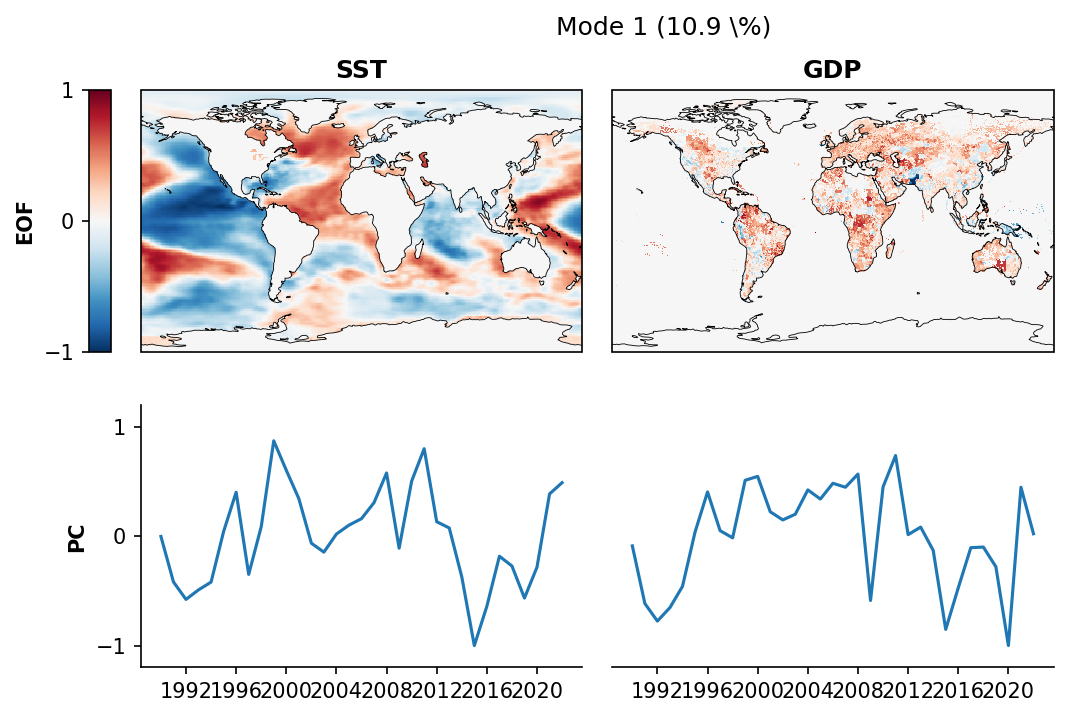

In [ ]:
mca.set_field_names('SST', 'GDP')
pkwargs = {'orientation' : 'vertical'}
mca.plot(mode=1, **pkwargs)